In [1]:
import importlib
import quantum_function
importlib.reload(quantum_function)

from quantum_function import *
from IPython.display import display, Markdown

In [2]:
# --- SAFETY SWITCH: esce subito se non abiliti esplicitamente ---
RUN_THIS_CELL = True   # metti True solo quando vuoi davvero eseguire

if not RUN_THIS_CELL:
    display(Markdown("**🔒 Cell locked. Set `RUN_THIS_CELL = True` to run.**"))
    raise SystemExit

my_directory = ".\\Graphs\\Jz_1_Photodetection"

plt.rcParams["text.usetex"] = True
plt.rcParams.update({
    "mathtext.fontset": "cm",      # font simile a LaTeX
    "font.family": "serif",
    "font.size": 14,
    "axes.unicode_minus": False
})

<font size="6">***Entanglement of a pair of quantum emitters via Jz***

### <u> Spin operators in bipartite system </u>

- For a spin-1/2 the spin operator (adopting natural units $\hbar=1$) is:

$$
S_z = \frac{1}{2}
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
$$

setting $|e\rangle = \begin{pmatrix}1\\0\end{pmatrix}$ (spin up, 1/2) and 
$|g\rangle = \begin{pmatrix}0\\1\end{pmatrix}$ (spin down, -1/2).

- In a two qubit system, in the basis:
$$
\{|ee\rangle,\,|eg\rangle,\,|ge\rangle,\,|gg\rangle\}
$$

we have:

$$
S_{z1} = S_z \otimes \mathbb{I} =
\frac{1}{2}
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & -1 & 0 \\
0 & 0 & 0 & -1
\end{pmatrix}
$$

$$
S_{z2} = \mathbb{I} \otimes S_z =
\frac{1}{2}
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & -1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & -1
\end{pmatrix}
$$


We consider a setup where an initial two-qubit state $\rho$ is continuously monitored via different methods: photodetection, homodyne and heterodyne detection. 

We start with the simplest one: photodetection in the ideal case where $ \eta_1 = \eta_2 = 1$. We analyze some Css states,

$$|\theta, \phi\rangle = \bigotimes_{i=1}^N \left( e^{i\phi}\sin\frac{\theta}{2}\,|1\rangle_i +  \cos\frac{\theta}{2}\,|0\rangle_i \right)$$

 in particular:
$$
{|ee\rangle, |++ \rangle}
$$

# Ideal case: Avg concurrence of Css states, $\theta = 0$

In [3]:
#1000 in 2 min

gamma = 1             # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) # time vector

my_name_states = ["ee","++","css_theta=pi/3","css_theta=pi/4","css_theta=pi/6"]

my_initial_states = [
    ee,
    css_2(np.pi/2, phi=0),
    css_2(np.pi/3, phi=0),
    css_2(np.pi/4, phi=0),
    css_2(np.pi/6, phi=0)
]

theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

ntraj = 100 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma / 2) * (Sz_1-Sz_2)
        ],
        e_ops=[concurrence_for_solver_pure],
        ntraj=ntraj,
        options={"keep_runs_results": True, "map":"parallel"}, #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)

10.0%. Run time:   9.86s. Est. time left: 00:00:01:28
20.0%. Run time:   9.99s. Est. time left: 00:00:00:39
30.0%. Run time:  10.10s. Est. time left: 00:00:00:23
40.0%. Run time:  10.20s. Est. time left: 00:00:00:15
50.0%. Run time:  10.32s. Est. time left: 00:00:00:10
60.0%. Run time:  10.41s. Est. time left: 00:00:00:06
70.0%. Run time:  10.53s. Est. time left: 00:00:00:04
80.0%. Run time:  10.68s. Est. time left: 00:00:00:02
90.0%. Run time:  10.77s. Est. time left: 00:00:00:01
100.0%. Run time:  10.98s. Est. time left: 00:00:00:00
Total run time:  12.04s
10.0%. Run time:   8.27s. Est. time left: 00:00:01:14
20.0%. Run time:   8.36s. Est. time left: 00:00:00:33
30.0%. Run time:   8.46s. Est. time left: 00:00:00:19
40.0%. Run time:   8.54s. Est. time left: 00:00:00:12
50.0%. Run time:   8.62s. Est. time left: 00:00:00:08
60.0%. Run time:   8.69s. Est. time left: 00:00:00:05
70.0%. Run time:   8.78s. Est. time left: 00:00:00:03
80.0%. Run time:   8.85s. Est. time left: 00:00:00:02
90.

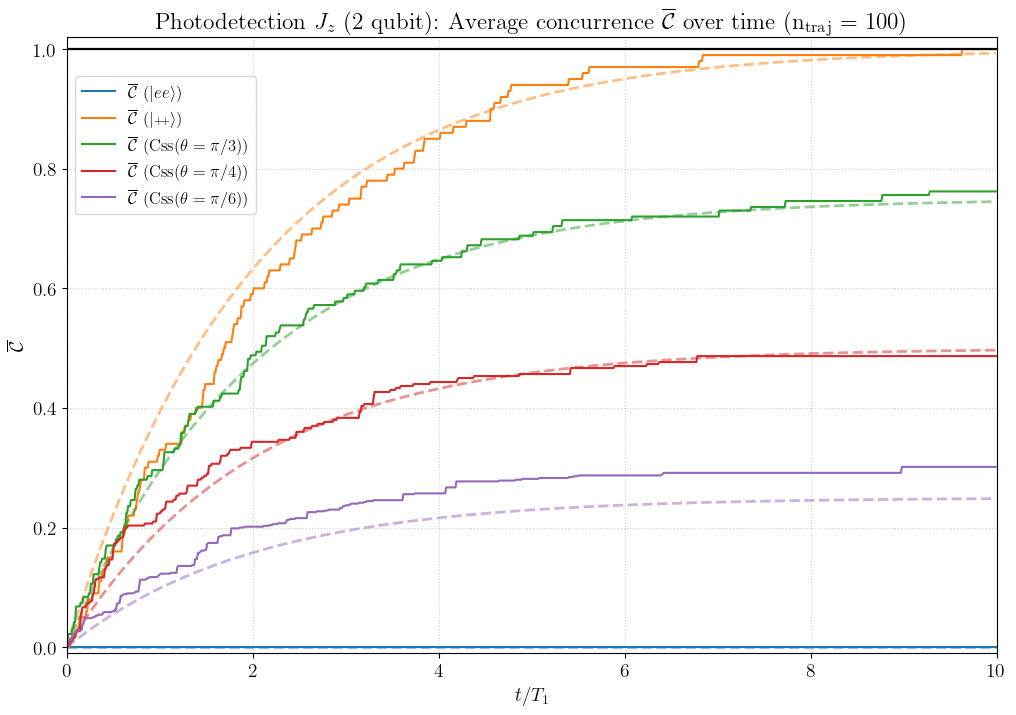

In [6]:
graph_name = "Concurrence_theta_=_0"

theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

#theo_curves = [
    #((1 - np.cos(2*theta)) / (3 + np.cos(2*theta))) * (1 - np.exp(-gamma/2 * times))
    #for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

plt.figure(figsize=(12,8))

for (name, df), theory in zip(photodetection_dfs.items(),theo_curves):
    # x: tempo normalizzato a T1, y: media delle traiettorie
    x = times/T_1
    y = df["mean"]
    line_sim, = plt.plot(x, y, label=label_states_sim(name))
    plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.ylim(-0.01, 1.02)
plt.xlim(0,10)

plt.axhline(1, color="k", linewidth=1.6, linestyle="-", zorder=5)
#plt.axhspan(1, 1.05, color="k", alpha=0.7, zorder=1, label="_nolegend_")

plt.xlabel(r"$t/T_1$")
plt.ylabel(r"$\overline{\mathcal{C}}$")
plt.title(r"Photodetection $J_z$ (2 qubit): Average concurrence $\overline{\mathcal{C}}$ over time"
          + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)

plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
plt.show()

# Ideal case: Avg spin squeezing KU of Css states, $\theta = 0$

In [125]:
#1000 in 2 min

gamma = 1             # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) # time vector

my_name_states = ["++","css_theta=pi/3","css_theta=pi/4","css_theta=pi/6","ee"]

my_initial_states = [
    css_2(np.pi/2, phi=0),
    css_2(np.pi/3, phi=0),
    css_2(np.pi/4, phi=0),
    css_2(np.pi/6, phi=0),
    ee
]

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

my_opts_dict = {
    "keep_runs_results": True,
    "map":"parallel",
    #"normalize_output" : False,
    #"store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }

ntraj = 10000 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma / 2) * (Sz_1-Sz_2)
        ],
        e_ops=[xi_KU_solver],
        ntraj=ntraj,
        options=my_opts_dict
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)

10.0%. Run time: 150.75s. Est. time left: 00:00:22:36
20.0%. Run time: 301.53s. Est. time left: 00:00:20:06
30.0%. Run time: 445.39s. Est. time left: 00:00:17:19
40.0%. Run time: 574.36s. Est. time left: 00:00:14:21
50.0%. Run time: 708.84s. Est. time left: 00:00:11:48
60.0%. Run time: 839.44s. Est. time left: 00:00:09:19
70.0%. Run time: 978.04s. Est. time left: 00:00:06:59
80.0%. Run time: 1111.60s. Est. time left: 00:00:04:37
90.0%. Run time: 1244.39s. Est. time left: 00:00:02:18
100.0%. Run time: 1375.31s. Est. time left: 00:00:00:00
Total run time: 1380.19s
10.0%. Run time: 168.92s. Est. time left: 00:00:25:20
20.0%. Run time: 325.71s. Est. time left: 00:00:21:42
30.0%. Run time: 478.67s. Est. time left: 00:00:18:36
40.0%. Run time: 629.79s. Est. time left: 00:00:15:44
50.0%. Run time: 782.71s. Est. time left: 00:00:13:02
60.0%. Run time: 979.64s. Est. time left: 00:00:10:53
70.0%. Run time: 1145.25s. Est. time left: 00:00:08:10
80.0%. Run time: 1306.65s. Est. time left: 00:00:05:

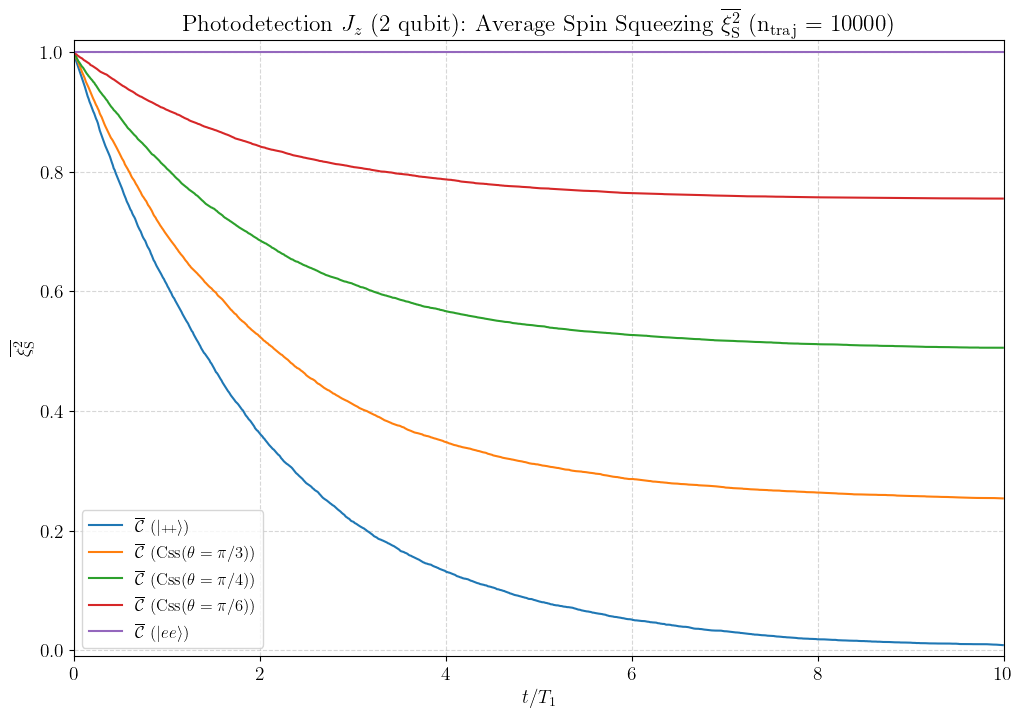

In [126]:
graph_name = "SpinSqueezingKU_theta_=_0"

theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

plt.figure(figsize=(12,8))

for (name, df), theory in zip(photodetection_dfs.items(),theo_curves):
    # x: tempo normalizzato a T1, y: media delle traiettorie
    x = times/T_1
    y = df["mean"]
    line_sim, = plt.plot(x, y, label=label_states_sim(name))
    #plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.ylim(-0.01, 1.02)
plt.xlim(0,10)

plt.xlabel(r"$t/T_1$")
plt.ylabel(r"$\overline{\xi_{\scriptstyle \mathrm{S}}^{2}}$")
plt.title(r"Photodetection $J_z$ (2 qubit): Average Spin Squeezing $\overline{\xi_{\scriptstyle \mathrm{S}}^{2}}$"
          + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
plt.grid(True, linestyle="dashed", alpha=0.5)
plt.legend(loc="best", fontsize=12)

# Salvataggio opzionale ad alta qualità
plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
plt.show()

## VARYING LAMBDA, PHASE PLATE AT THE SECOND PORT (NEGATIVE COMBINATION)

## Ideal case: Avg concurrence of $|++\rangle$ for different $\lambda$ angles = [0, 30°, 45°, 60°, 90°]

In [ ]:
#1000 in 1 min

gamma = 1             # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) # time vector

my_angles = [0, 1/6, 1/4, 1/3, 1/2] # angles for the homodyne detection
my_name_angles = ["0","pi/6","pi/4","pi/3","pi/2"]

state = PlusPlus

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

my_opts_dict = {
    "keep_runs_results": True,
    "map":"parallel",
    #"normalize_output" : False,
    #"store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }   

ntraj = 1000 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_angle, angle in zip(my_name_angles, my_angles):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (Sz_1+Sz_2),
        np.exp(1j * np.pi* angle) * np.sqrt(gamma / 2) * (Sz_1-Sz_2)
        ],
        e_ops=[concurrence_for_solver_pure],
        ntraj=ntraj,
        options=my_opts_dict
    )

    photodetection_dfs[f"{name_angle}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_angle}"].index = np.arange(1, photodetection_dfs[f"{name_angle}"].shape[0]+1)
    photodetection_dfs[f"{name_angle}"].index.name = "Step"
    photodetection_dfs[f"{name_angle}"]['mean'] = photodetection_dfs[f"{name_angle}"].mean(axis=1)

10.0%. Run time:  10.26s. Est. time left: 00:00:01:32
20.0%. Run time:  10.59s. Est. time left: 00:00:00:42
30.0%. Run time:  10.98s. Est. time left: 00:00:00:25
40.0%. Run time:  11.39s. Est. time left: 00:00:00:17
50.0%. Run time:  11.77s. Est. time left: 00:00:00:11
60.0%. Run time:  12.06s. Est. time left: 00:00:00:08
70.0%. Run time:  12.37s. Est. time left: 00:00:00:05
80.0%. Run time:  12.65s. Est. time left: 00:00:00:03
90.0%. Run time:  12.95s. Est. time left: 00:00:00:01
100.0%. Run time:  13.23s. Est. time left: 00:00:00:00
Total run time:  14.30s
10.0%. Run time:   8.42s. Est. time left: 00:00:01:15
20.0%. Run time:   8.74s. Est. time left: 00:00:00:34
30.0%. Run time:   9.00s. Est. time left: 00:00:00:21
40.0%. Run time:   9.24s. Est. time left: 00:00:00:13
50.0%. Run time:   9.47s. Est. time left: 00:00:00:09
60.0%. Run time:   9.71s. Est. time left: 00:00:00:06
70.0%. Run time:   9.94s. Est. time left: 00:00:00:04
80.0%. Run time:  10.19s. Est. time left: 00:00:00:02
90.

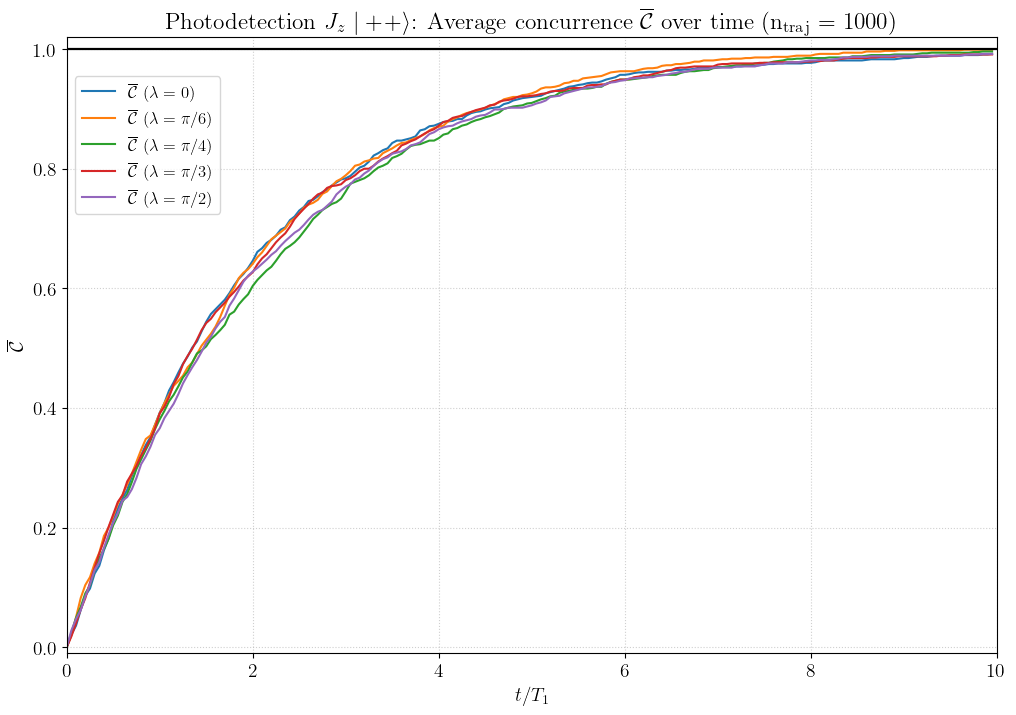

In [36]:
graph_name = "Concurrence_++_lambdas"

theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

plt.figure(figsize=(12,8))

for (name, df), theory in zip(photodetection_dfs.items(),theo_curves):
    # x: tempo normalizzato a T1, y: media delle traiettorie
    x = times/T_1
    y = df["mean"]
    line_sim, = plt.plot(x, y, label=label_states_sim(name))
    #plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.ylim(-0.01, 1.02)
plt.xlim(0,10)

plt.axhline(1, color="k", linewidth=1.6, linestyle="-", zorder=5)
#plt.axhspan(1, 1.05, color="k", alpha=0.7, zorder=1, label="_nolegend_")

plt.xlabel(r"$t/T_1$")
plt.ylabel(r"$\overline{\mathcal{C}}$")
plt.title(r"Photodetection $J_z$ $|+\!+\rangle$: Average concurrence $\overline{\mathcal{C}}$ over time"
          + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)

# Salvataggio opzionale ad alta qualità
plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
plt.show()

# Ideal case: Avg spin squeezing KU of Css states, $\theta = 0$

In [ ]:
#1000 in 2 min

gamma = 1             # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) # time vector

my_angles = [0, 1/6, 1/4, 1/3, 1/2] # angles for the homodyne detection
my_name_angles = ["0","pi/6","pi/4","pi/3","pi/2"]

state = PlusPlus

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

my_opts_dict = {
    "keep_runs_results": True,
    "map":"parallel",
    #"normalize_output" : False,
    #"store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }   

ntraj = 1000 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_angle, angle in zip(my_name_angles, my_angles):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (Sz_1+Sz_2),
        np.exp(1j * np.pi* angle) * np.sqrt(gamma / 2) * (Sz_1-Sz_2)
        ],
        e_ops=[xi_KU_solver],
        ntraj=ntraj,
        options=my_opts_dict
    )

    photodetection_dfs[f"{name_angle}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_angle}"].index = np.arange(1, photodetection_dfs[f"{name_angle}"].shape[0]+1)
    photodetection_dfs[f"{name_angle}"].index.name = "Step"
    photodetection_dfs[f"{name_angle}"]['mean'] = photodetection_dfs[f"{name_angle}"].mean(axis=1)

10.0%. Run time:  10.73s. Est. time left: 00:00:01:36
20.0%. Run time:  11.61s. Est. time left: 00:00:00:46
30.0%. Run time:  12.51s. Est. time left: 00:00:00:29
40.0%. Run time:  13.28s. Est. time left: 00:00:00:19
50.0%. Run time:  13.95s. Est. time left: 00:00:00:13
60.0%. Run time:  14.63s. Est. time left: 00:00:00:09
70.0%. Run time:  15.54s. Est. time left: 00:00:00:06
80.0%. Run time:  16.35s. Est. time left: 00:00:00:04
90.0%. Run time:  17.05s. Est. time left: 00:00:00:01
100.0%. Run time:  17.80s. Est. time left: 00:00:00:00
Total run time:  19.20s
10.0%. Run time:   8.47s. Est. time left: 00:00:01:16
20.0%. Run time:   9.01s. Est. time left: 00:00:00:36
30.0%. Run time:   9.53s. Est. time left: 00:00:00:22
40.0%. Run time:  10.18s. Est. time left: 00:00:00:15
50.0%. Run time:  10.71s. Est. time left: 00:00:00:10
60.0%. Run time:  11.19s. Est. time left: 00:00:00:07
70.0%. Run time:  11.69s. Est. time left: 00:00:00:05
80.0%. Run time:  12.24s. Est. time left: 00:00:00:03
90.

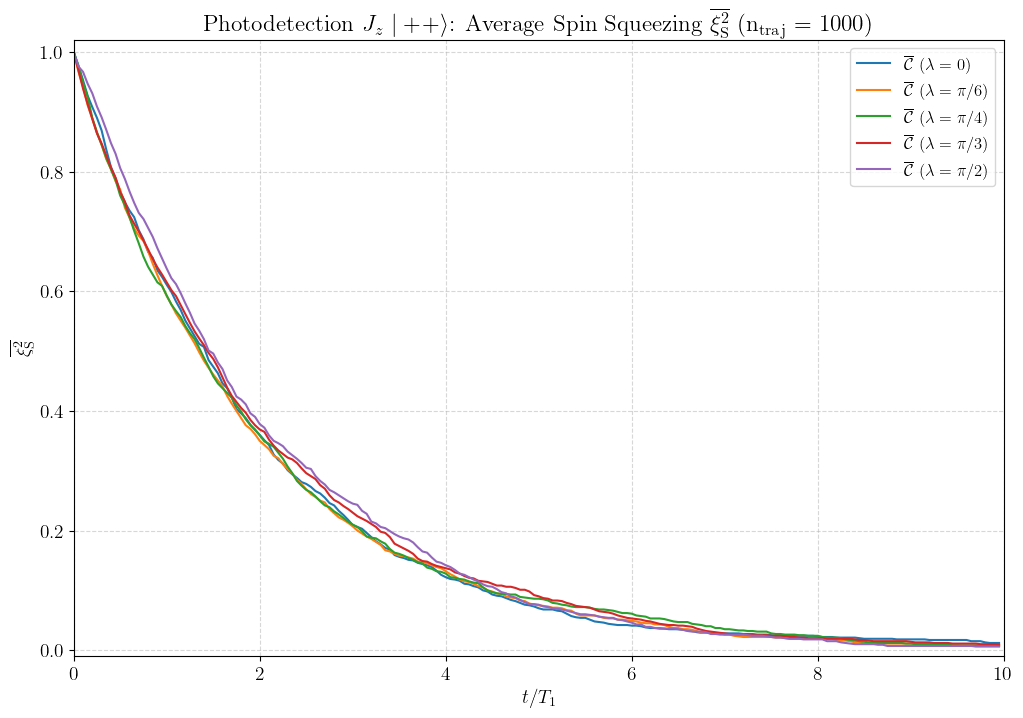

In [ ]:
graph_name = "SpinSqueezingKU_++_lambdas"

theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

plt.figure(figsize=(12,8))

for (name, df), theory in zip(photodetection_dfs.items(),theo_curves):
    # x: tempo normalizzato a T1, y: media delle traiettorie
    x = times/T_1
    y = df["mean"]
    line_sim, = plt.plot(x, y, label=label_states_sim(name))
    #plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.ylim(-0.01, 1.02)
plt.xlim(0,10)

plt.xlabel(r"$t/T_1$")
plt.ylabel(r"$\overline{\xi_{\scriptstyle \mathrm{S}}^{2}}$")
plt.title(r"Photodetection $J_z$ $|+\!+\rangle$: Average Spin Squeezing $\overline{\xi_{\scriptstyle \mathrm{S}}^{2}}$"
          + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
plt.grid(True, linestyle="dashed", alpha=0.5)
plt.legend(loc="best", fontsize=12)

# Salvataggio opzionale ad alta qualità
plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
plt.show()

# Jump statistics

### Let's start with $|++\rangle$, $\lambda$=0

In [101]:
# Voglio studiare le traiettorie singole per capire meglio il fenomeno, calcolando la fidelity con gli stati di Bell

gamma = 1             # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) # time vector

state = PlusPlus

#Creo dict di dataframe per ogni stato iniziale
fidelity_df = {}

ntraj = 100 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
my_photodetection = mcsolve(
    H_free, state, times,
    c_ops = [
    np.sqrt(gamma / 2) * (Sz_1+Sz_2),
    np.sqrt(gamma / 2) * (Sz_1-Sz_2)
    ],
    e_ops=fidelity_ops,
    ntraj=ntraj,
    options={"keep_runs_results": True, "map":"parallel"}, #Necessary to create the keep the e_ops results for each trajectory
)

10.0%. Run time:  37.48s. Est. time left: 00:00:05:37
20.0%. Run time:  37.65s. Est. time left: 00:00:02:30
30.0%. Run time:  37.92s. Est. time left: 00:00:01:28
40.0%. Run time:  38.09s. Est. time left: 00:00:00:57
50.0%. Run time:  38.28s. Est. time left: 00:00:00:38
60.0%. Run time:  38.44s. Est. time left: 00:00:00:25
70.0%. Run time:  38.58s. Est. time left: 00:00:00:16
80.0%. Run time:  38.70s. Est. time left: 00:00:00:09
90.0%. Run time:  38.84s. Est. time left: 00:00:00:04
100.0%. Run time:  38.95s. Est. time left: 00:00:00:00
Total run time:  40.06s


In [102]:
# Etichette leggibili per i 4 e_ops
bell_labels = ["phi_plus", "phi_minus", "psi_plus", "psi_minus"]

# Sanity check e dimensioni
runs = my_photodetection.runs_e_data
assert runs, "keep_runs_results=True ma .runs è vuoto. Controlla le options di mcsolve."
n_ops = len(runs)
ntraj = len(runs[0])
nt = len(times)
assert n_ops == 4, f"Mi aspetto 4 e_ops (Bell), ne vedo {n_ops}."

# Costruisco un array (n_ops, ntraj, nt) con tutte le fidelity
data = np.empty((ntraj, n_ops, nt), dtype=float)

for fidelity in range(n_ops):
    for traj in range(ntraj):
        for t in range(nt):
            data[traj, fidelity, t] = runs[fidelity][traj][t]

# ---------------------------
# 1) DATAFRAME "WIDE" (MultiIndex sulle colonne: Bell × Trajectory)
# righe = tempo t; colonne = (Traj, Bell state fidelity)
# ---------------------------

# data ha shape (ntraj, n_ops, nt)  <-- come nel tuo codice di riempimento
# se per caso l’hai con (n_ops, ntraj, nt), fai: data = np.transpose(data, (1,0,2))

# MultiIndex: per ogni Traj_j ripeto le 4 etichette Bell
traj_labels = sum([[f"Traj_{j+1}"] * n_ops for j in range(ntraj)], [])
bell_labels_rep = bell_labels * ntraj  # ["phi_plus",...,"psi_minus"] ripetuto per ogni Traj_j

cols = pd.MultiIndex.from_arrays([traj_labels, bell_labels_rep],
                                 names=["Trajectory", "Bell state"])

# Appiattisco i primi due assi nell’ordine desiderato: (Traj major, Bell minor)
fidelity_df = pd.DataFrame(
    data.reshape(ntraj * n_ops, nt).T,   # (nt, ntraj*n_ops)
    index=pd.Index(times, name="t"),
    columns=cols
)

# Aggiungo la colonna con lo stato di Bell corrispondente ad ogni fidelity
# +2 per phi_plus, +1 per phi_minus, -1 per psi_minus, -2 per psi_plus
fidelity_df = add_state_columns(fidelity_df)

# Se vuoi dare un’occhiata a una traiettoria:
# fidelity_with_state.xs("Traj_1", axis=1, level="Trajectory").head()

c:\Users\campa\OneDrive\Desktop\Master Thesis\Stochastic_Master_Thesis\Codes\quantum_function.py:664: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[(tr, "state")] = state


In [96]:
#fidelity_df

In [ ]:
# Fidelity medie su TUTTE le traiettorie, una curva per ogni Bell
#mean_per_bell = fidelity_df.groupby(level="Bell state", axis=1).mean()

# Seleziona solo Traj_3 (tutte e 4 le fidelity come colonne semplici)
#traj3 = fidelity_df.xs("Traj_3", axis=1, level="Trajectory")

# Seleziona solo psi_minus su tutte le traiettorie
states_all = fidelity_df.xs("state", axis=1, level="Bell state")

C:\Users\campa\AppData\Local\Temp\ipykernel_8400\1542053535.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_per_bell = fidelity_df.groupby(level="Bell state", axis=1).mean()


In [ ]:
df_plot = states_all.iloc[:, :6]

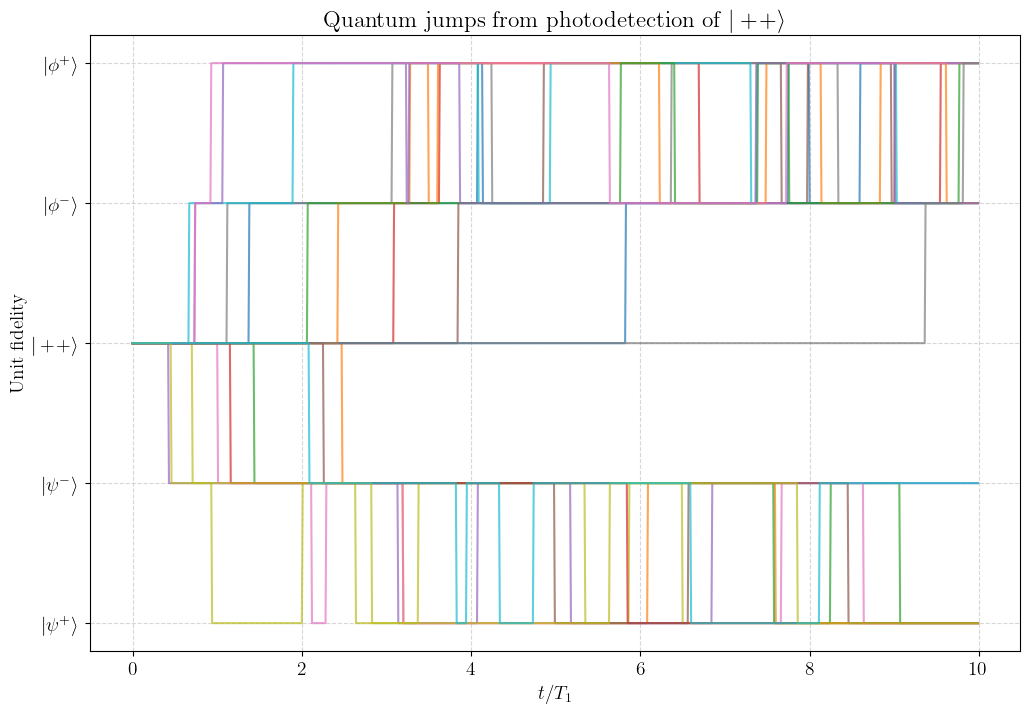

In [ ]:
plt.figure(figsize=(12,8))

plt.plot(df_plot.index/T_1, df_plot, alpha=0.7)


plt.xlabel(r"$t/T_1$")
plt.ylabel(r"Unit fidelity")


# posizioni verticali che stai già usando
y_odd_plus,  y_odd_minus  = -2, -1
y_even_plus, y_even_minus = +2, +1
y_plusplus = 0

positions = [y_odd_plus, y_odd_minus, y_even_plus, y_even_minus, y_plusplus]
labels = [r"$|\psi^+\rangle$", r"$|\psi^-\rangle$",
          r"$|\phi^+\rangle$", r"$|\phi^-\rangle$", r"$|+\!+\rangle$"]

plt.yticks(positions, labels)   # <-- NON plt.yticklabels

plt.title(r"Quantum jumps from photodetection of $|+\!+\rangle$")
plt.grid(True, linestyle="dashed", alpha=0.5)
#plt.legend(loc="best", fontsize=12)


plt.show()

# ROBA VECCHIA!

## Inefficient case for $|++\rangle$
$$\eta_{1} = \eta_{2} \neq 1$$

In [ ]:
#1000 in 2 min

gamma = 1             # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) # time vector

my_name_states = ["ee","++","css_theta=pi/3","css_theta=pi/4","css_theta=pi/6"]

my_initial_states = [
    ee,
    css_2(np.pi/2, phi=0),
    css_2(np.pi/3, phi=0),
    css_2(np.pi/4, phi=0),
    css_2(np.pi/6, phi=0)
]

theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

ntraj = 1000 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = mcsolve(
        H_free, state, times,

        c_ops = [
        np.sqrt(gamma*eta / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma*eta / 2) * (Sz_1-Sz_2)
        ],

        sc_ops = [
        np.sqrt(gamma*(1-eta) / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma*(1-eta) / 2) * (Sz_1-Sz_2)
        ],
        e_ops=[concurrence_for_solver_pure],
        ntraj=ntraj,
        options={"keep_runs_results": True, "map":"parallel"}, #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)


10.0%. Run time:  15.50s. Est. time left: 00:00:02:19
20.0%. Run time:  19.77s. Est. time left: 00:00:01:19
30.0%. Run time:  24.47s. Est. time left: 00:00:00:57
40.0%. Run time:  28.68s. Est. time left: 00:00:00:43
50.0%. Run time:  34.82s. Est. time left: 00:00:00:34
60.0%. Run time:  39.72s. Est. time left: 00:00:00:26
70.0%. Run time:  44.54s. Est. time left: 00:00:00:19
80.0%. Run time:  48.94s. Est. time left: 00:00:00:12
90.0%. Run time:  55.21s. Est. time left: 00:00:00:06
100.0%. Run time:  58.42s. Est. time left: 00:00:00:00
Total run time:  59.36s
10.0%. Run time:  14.68s. Est. time left: 00:00:02:12
20.0%. Run time:  18.99s. Est. time left: 00:00:01:15
30.0%. Run time:  23.26s. Est. time left: 00:00:00:54
40.0%. Run time:  27.83s. Est. time left: 00:00:00:41
50.0%. Run time:  34.47s. Est. time left: 00:00:00:34
60.0%. Run time:  38.82s. Est. time left: 00:00:00:25
70.0%. Run time:  43.80s. Est. time left: 00:00:00:18
80.0%. Run time:  48.41s. Est. time left: 00:00:00:12
90.

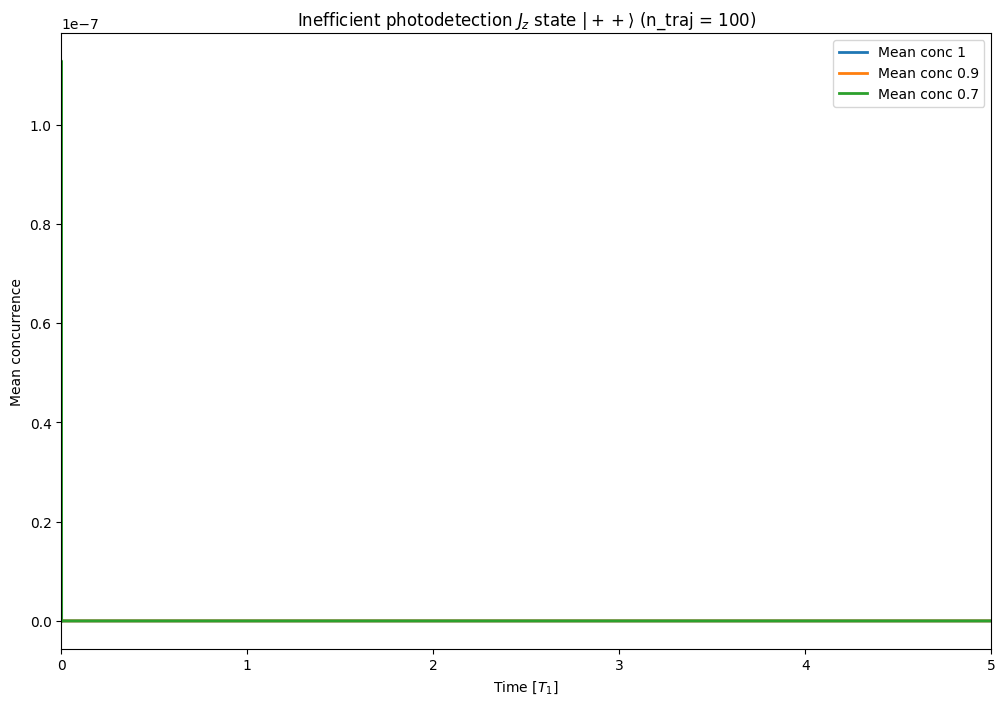

In [3]:
plt.figure(figsize=(12,8))

for eta in my_eta:
    line_sim, = plt.plot(times/T_1, photodetection_dfs[f"{eta}"]['mean'], label=f"Mean conc {eta}", linewidth=2)
    
plt.xlim(0, 5)
plt.xlabel(r"Time [$T_1$]")
plt.ylabel("Mean concurrence")
plt.title(fr"Inefficient photodetection $J_z$ state $|++\rangle$ (n_traj = {ntraj})")
plt.legend()
plt.show()

In [4]:
# 1) Definisci una sola volta i canali fisici C±
C_plus  = np.sqrt(gamma)/np.sqrt(2) * (Sz_1 + Sz_2)
C_minus = np.sqrt(gamma)/np.sqrt(2) * (Sz_1 - Sz_2)

def conc_rho(t, rho):   # e_op per densità a due qubit
    return concurrence(rho)

photodetection_dfs = {}
ntraj = 100

for eta in my_eta:
    res = smesolve(
        H_free,
        state*state.dag(),            # rho0 (usa densità)
        times,
        # canali NON osservati (perdita)
        c_ops=[ np.sqrt(1-eta)*C_plus, np.sqrt(1-eta)*C_minus ],
        # canali OSSERVATI (fotocorrente)
        sc_ops=[ np.sqrt(eta)*C_plus,  np.sqrt(eta)*C_minus  ],
        e_ops=[conc_rho],              # concurrence su rho
        ntraj=ntraj,
        store_all_expect=True,         # per avere ogni traiettoria
        store_measurement=False,       # True se vuoi anche i dN
    )

    # res.runs_expect[0] è una lista lunga ntraj, ciascuna un array (len(times),)
    traj_cols = [np.asarray(tr) for tr in res.runs_expect[0]]
    df = pd.DataFrame(np.column_stack(traj_cols), columns=[f"Traj_{i+1}" for i in range(ntraj)])
    df['mean'] = df.mean(axis=1)
    photodetection_dfs[f"{eta}"] = df


c:\Users\campa\OneDrive\Desktop\Master Thesis\Stochastic_Master_Thesis\Giga_SMT_venv\Lib\site-packages\qutip\solver\solver_base.py:551: FutureWarning: The "store_all_expect" parameter is now the "keep_runs_results" options:
Use `options={"keep_runs_results": False / True}`
  warnings.warn(
c:\Users\campa\OneDrive\Desktop\Master Thesis\Stochastic_Master_Thesis\Giga_SMT_venv\Lib\site-packages\qutip\solver\solver_base.py:560: FutureWarning: The "store_measurement" parameter is now an options:
Use `options={"store_measurement": False / True}`
  warnings.warn(


10.0%. Run time:  21.69s. Est. time left: 00:00:03:15
20.0%. Run time:  46.69s. Est. time left: 00:00:03:06
30.0%. Run time:  72.22s. Est. time left: 00:00:02:48
40.0%. Run time:  99.18s. Est. time left: 00:00:02:28
50.0%. Run time: 120.76s. Est. time left: 00:00:02:00
60.0%. Run time: 141.16s. Est. time left: 00:00:01:34
70.0%. Run time: 161.39s. Est. time left: 00:00:01:09
80.0%. Run time: 180.16s. Est. time left: 00:00:00:45


KeyboardInterrupt: 

# Spin Squeezing

The concept of *spin squeezing* originates from the idea of coherent spin states (CSS), introduced and formalized by Kitagawa and Ueda (1993), and later developed in a metrological context by Wineland and collaborators (1994).

---

## Coherent Spin States (CSS)

A coherent spin state is the many-particle (spin-1/2 ensemble) analogue of an optical coherent state.  

$$|\text{CSS}(\theta, \phi)\rangle = \bigotimes_{i=1}^N \left( e^{i\phi}\sin\frac{\theta}{2}\,|1\rangle_i +  \cos\frac{\theta}{2}\,|0\rangle_i \right)
$$

In a CSS, all spins point in the same direction, and transverse quantum fluctuations obey the standard quantum limit:

$$
(\Delta J_\perp)^2 = \frac{N}{2},
$$

where $N$ is the number of particles and $J_\perp$ is a collective spin component orthogonal to the mean spin direction.

---

## Mean Spin Direction (MSD)

In the context of collective spin systems, the **Mean Spin Direction (MSD)** is defined as the normalized expectation value of the collective spin operator:

$$
\vec{J} = (J_x, J_y, J_z), \qquad
\langle \vec{J} \rangle = \big( \langle J_x \rangle, \langle J_y \rangle, \langle J_z \rangle \big).
$$

The **MSD** is then given by:

$$
\hat{n}_{\text{MSD}} = \frac{\langle \vec{J} \rangle}{|\langle \vec{J} \rangle|}.
$$

---

### Role in Spin Squeezing

- The MSD determines the **reference axis** along which the collective spin is aligned.
- Spin squeezing is defined with respect to fluctuations in directions **orthogonal** to the MSD.
- In a **Coherent Spin State (CSS)**, all spins are aligned, so the MSD is well-defined and points along the macroscopic spin direction.
- In squeezed states, uncertainty is redistributed among components transverse to the MSD, while the mean spin length typically decreases due to entanglement.

---

**Example:**  
- For a CSS pointing along the $x$-axis, the MSD is $\hat{n}_{\text{MSD}} = \hat{x}$.  
- Variances $(\Delta J_y)^2$ and $(\Delta J_z)^2$ define the transverse quantum noise ellipse relative to this direction.

---

## Definition of Spin Squeezing

- **Kitagawa-Ueda (1993):**  
  A state is *spin-squeezed* if the variance of a collective spin component transverse to the mean spin is reduced below that of a CSS:

  $$
  \xi_{\text{KU}}^2 = \frac{N (\Delta J_\perp)^2}{\langle J \rangle^2} < 1
  $$

- **Wineland et al. (1994):**  
  connected spin squeezing to quantum metrology, defining a parameter that quantifies the improvement in phase sensitivity compared to the standard quantum limit (SQL):

  $$
  \xi_{\text{W}}^2 = \frac{N (\Delta J_\perp)^2}{\langle J_z \rangle^2}.
  $$

---

## Physical Meaning

- Spin-squeezed states reduce uncertainty in one spin quadrature at the expense of increased uncertainty in the conjugate quadrature, in accordance with the Heisenberg uncertainty principle.
- They provide a useful resource for:
  - **quantum metrology** (phase and frequency estimation),
  - **atomic clocks**,
  - **witnessing entanglement** in many-body systems.

In short, spin squeezing is a form of useful entanglement that enables measurements beyond the standard quantum limit, approaching the Heisenberg limit.


## Spin squeezing by Kitagawa-ueda

In [ ]:
gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) # time vector

my_name_states = ["ee","++","css_theta=pi/3","css_theta=pi/4","css_theta=pi/6"]

my_initial_states = [
    ee,
    css_2(np.pi/2, phi=0),
    css_2(np.pi/3, phi=0),
    css_2(np.pi/4, phi=0),
    css_2(np.pi/6, phi=0)
]

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

ntraj = 500 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma / 2) * (Sz_1-Sz_2)
        ],
        e_ops=[spin_squeezing_KU_solver],
        ntraj=ntraj,
        options={"keep_runs_results": True}, #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)


10.0%. Run time:   2.53s. Est. time left: 00:00:00:22
20.0%. Run time:   4.88s. Est. time left: 00:00:00:19
30.0%. Run time:   7.53s. Est. time left: 00:00:00:17
40.0%. Run time:  10.99s. Est. time left: 00:00:00:16
50.0%. Run time:  14.28s. Est. time left: 00:00:00:14
60.0%. Run time:  17.00s. Est. time left: 00:00:00:11
70.0%. Run time:  19.61s. Est. time left: 00:00:00:08
80.0%. Run time:  22.34s. Est. time left: 00:00:00:05
90.0%. Run time:  25.63s. Est. time left: 00:00:00:02
100.0%. Run time:  28.23s. Est. time left: 00:00:00:00
Total run time:  28.28s
10.0%. Run time:   4.42s. Est. time left: 00:00:00:39
20.0%. Run time:   8.52s. Est. time left: 00:00:00:34
30.0%. Run time:  13.12s. Est. time left: 00:00:00:30
40.0%. Run time:  17.44s. Est. time left: 00:00:00:26
50.0%. Run time:  21.76s. Est. time left: 00:00:00:21
60.0%. Run time:  26.45s. Est. time left: 00:00:00:17
70.0%. Run time:  31.31s. Est. time left: 00:00:00:13
80.0%. Run time:  36.10s. Est. time left: 00:00:00:09
90.

KU_spin squeezing è 0 per |ee> perché autostato di Jz. La varianza su un asse perpendicolare, ossia sul piano x-y è 0

In [ ]:
#my_state = css_2(np.pi/2, 0)
peres = [peres_horodecki_test(state) for state in my_initial_states]
KU = [spin_squeezing_KU(state) for state in my_initial_states]

peres, KU

([1, 1, 1, 1, 1],
 [0,
  np.float64(1.0),
  np.float64(1.0),
  np.float64(0.9999999999999999),
  np.float64(1.0)])

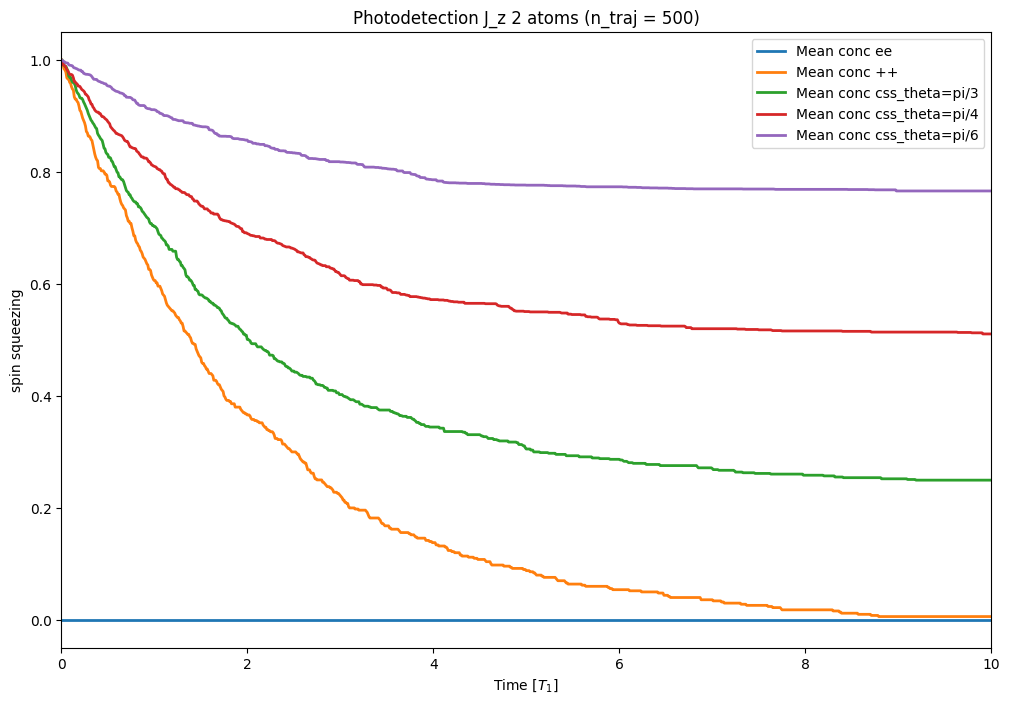

In [28]:
plt.figure(figsize=(12,8))

theo_curves = [(1-np.exp(-2*gamma * times))*np.sin(np.pi/(2*theta)) for theta in [1,2,3,4,6]]

for state,theory in zip(my_name_states, theo_curves):
    line_sim, = plt.plot(times/T_1, photodetection_dfs[f"{state}"]['mean'], label=f"Mean conc {state}", linewidth=2)
    #plt.plot(times/T_1, theory, '--', label=f"Theo conc", color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.xlim(0, 10)
plt.xlabel(r"Time [$T_1$]")
plt.ylabel("spin squeezing")
plt.title(f"Photodetection J_z 2 atoms (n_traj = {ntraj})")
plt.legend()
plt.show()

In [ ]:
gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) # time vector

my_name_states = ["ee","++","css_theta=pi/3","css_theta=pi/4","css_theta=pi/6"]

my_initial_states = [
    ee,
    css_2(np.pi/2, phi=0),
    css_2(np.pi/3, phi=0),
    css_2(np.pi/4, phi=0),
    css_2(np.pi/6, phi=0)
]

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

ntraj = 500 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma / 2) * (Sz_1-Sz_2)
        ],
        e_ops=[spin_squeezing_W_solver],
        ntraj=ntraj,
        options={"keep_runs_results": True}, #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)


10.0%. Run time:   0.66s. Est. time left: 00:00:00:05
20.0%. Run time:   1.32s. Est. time left: 00:00:00:05
30.0%. Run time:   2.35s. Est. time left: 00:00:00:05
40.0%. Run time:   3.52s. Est. time left: 00:00:00:05
50.0%. Run time:   4.21s. Est. time left: 00:00:00:04
60.0%. Run time:   4.90s. Est. time left: 00:00:00:03
70.0%. Run time:   5.61s. Est. time left: 00:00:00:02
80.0%. Run time:   6.42s. Est. time left: 00:00:00:01
90.0%. Run time:   7.37s. Est. time left: 00:00:00:00
100.0%. Run time:   8.54s. Est. time left: 00:00:00:00
Total run time:   8.70s


C:\Users\campa\AppData\Local\Temp\ipykernel_20244\598836297.py:149: RuntimeWarning: divide by zero encountered in scalar divide
  return spin_squeezing_KU(rho)*(2/(2*eval_J_norm(rho)))**2
C:\Users\campa\AppData\Local\Temp\ipykernel_20244\598836297.py:149: RuntimeWarning: invalid value encountered in scalar multiply
  return spin_squeezing_KU(rho)*(2/(2*eval_J_norm(rho)))**2


10.0%. Run time:   1.07s. Est. time left: 00:00:00:09
20.0%. Run time:   2.36s. Est. time left: 00:00:00:09
30.0%. Run time:   3.29s. Est. time left: 00:00:00:07
40.0%. Run time:   4.31s. Est. time left: 00:00:00:06
50.0%. Run time:   5.59s. Est. time left: 00:00:00:05
60.0%. Run time:   6.44s. Est. time left: 00:00:00:04
70.0%. Run time:   7.55s. Est. time left: 00:00:00:03
80.0%. Run time:   8.55s. Est. time left: 00:00:00:02
90.0%. Run time:   9.51s. Est. time left: 00:00:00:01
100.0%. Run time:  10.59s. Est. time left: 00:00:00:00
Total run time:  10.75s


C:\Users\campa\AppData\Local\Temp\ipykernel_20244\598836297.py:149: RuntimeWarning: divide by zero encountered in scalar divide
  return spin_squeezing_KU(rho)*(2/(2*eval_J_norm(rho)))**2
C:\Users\campa\AppData\Local\Temp\ipykernel_20244\598836297.py:149: RuntimeWarning: invalid value encountered in scalar multiply
  return spin_squeezing_KU(rho)*(2/(2*eval_J_norm(rho)))**2


10.0%. Run time:   1.99s. Est. time left: 00:00:00:17
20.0%. Run time:   4.45s. Est. time left: 00:00:00:17
30.0%. Run time:   6.76s. Est. time left: 00:00:00:15
40.0%. Run time:   8.49s. Est. time left: 00:00:00:12
50.0%. Run time:   9.94s. Est. time left: 00:00:00:09
60.0%. Run time:  12.48s. Est. time left: 00:00:00:08
70.0%. Run time:  14.99s. Est. time left: 00:00:00:06
80.0%. Run time:  17.88s. Est. time left: 00:00:00:04
90.0%. Run time:  19.96s. Est. time left: 00:00:00:02
100.0%. Run time:  23.45s. Est. time left: 00:00:00:00
Total run time:  23.77s


C:\Users\campa\AppData\Local\Temp\ipykernel_20244\598836297.py:149: RuntimeWarning: divide by zero encountered in scalar divide
  return spin_squeezing_KU(rho)*(2/(2*eval_J_norm(rho)))**2
C:\Users\campa\AppData\Local\Temp\ipykernel_20244\598836297.py:149: RuntimeWarning: invalid value encountered in scalar multiply
  return spin_squeezing_KU(rho)*(2/(2*eval_J_norm(rho)))**2


10.0%. Run time:   2.32s. Est. time left: 00:00:00:20
20.0%. Run time:   5.40s. Est. time left: 00:00:00:21
30.0%. Run time:   8.19s. Est. time left: 00:00:00:19
40.0%. Run time:  11.43s. Est. time left: 00:00:00:17
50.0%. Run time:  14.00s. Est. time left: 00:00:00:13
60.0%. Run time:  17.83s. Est. time left: 00:00:00:11
70.0%. Run time:  21.53s. Est. time left: 00:00:00:09
80.0%. Run time:  24.00s. Est. time left: 00:00:00:06
90.0%. Run time:  27.53s. Est. time left: 00:00:00:03
100.0%. Run time:  31.24s. Est. time left: 00:00:00:00
Total run time:  31.71s


C:\Users\campa\AppData\Local\Temp\ipykernel_20244\598836297.py:149: RuntimeWarning: divide by zero encountered in scalar divide
  return spin_squeezing_KU(rho)*(2/(2*eval_J_norm(rho)))**2
C:\Users\campa\AppData\Local\Temp\ipykernel_20244\598836297.py:149: RuntimeWarning: invalid value encountered in scalar multiply
  return spin_squeezing_KU(rho)*(2/(2*eval_J_norm(rho)))**2


10.0%. Run time:   2.72s. Est. time left: 00:00:00:24
20.0%. Run time:   6.92s. Est. time left: 00:00:00:27
30.0%. Run time:  10.56s. Est. time left: 00:00:00:24
40.0%. Run time:  13.88s. Est. time left: 00:00:00:20
50.0%. Run time:  17.76s. Est. time left: 00:00:00:17
60.0%. Run time:  21.88s. Est. time left: 00:00:00:14
70.0%. Run time:  25.58s. Est. time left: 00:00:00:10
80.0%. Run time:  29.32s. Est. time left: 00:00:00:07
90.0%. Run time:  33.16s. Est. time left: 00:00:00:03
100.0%. Run time:  36.50s. Est. time left: 00:00:00:00
Total run time:  36.78s


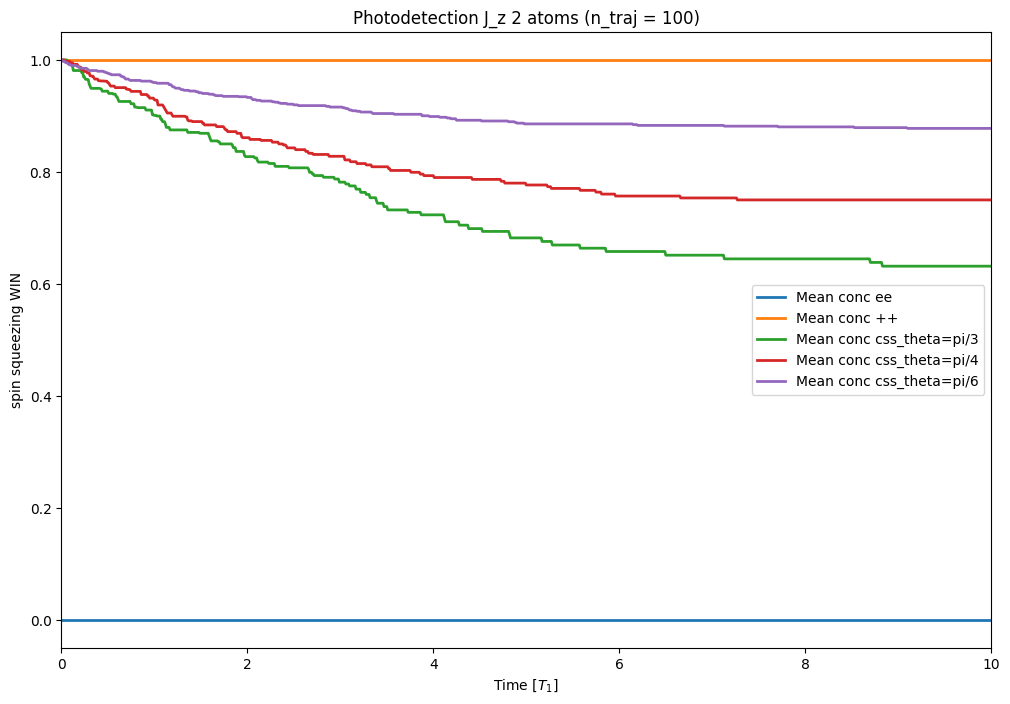

In [26]:
plt.figure(figsize=(12,8))

theo_curves = [(1-np.exp(-2*gamma * times))*np.sin(np.pi/(2*theta)) for theta in [1,2,3,4,6]]

for state,theory in zip(my_name_states, theo_curves):
    line_sim, = plt.plot(times/T_1, photodetection_dfs[f"{state}"]['mean'], label=f"Mean conc {state}", linewidth=2)
    #plt.plot(times/T_1, theory, '--', label=f"Theo conc", color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.xlim(0, 10)
plt.xlabel(r"Time [$T_1$]")
plt.ylabel("spin squeezing WIN")
plt.title(f"Photodetection J_z 2 atoms (n_traj = {ntraj})")
plt.legend()
plt.show()

## Usando Peres-Horodecki, 1 se separabile e 0 entangled (come spin squeezing)

In [ ]:
gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) # time vector

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

ntraj = 500 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma / 2) * (Sz_1-Sz_2)
        ],
        e_ops=[peres_horodecki_test_solver],
        ntraj=ntraj,
        options={"keep_runs_results": True}, #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)


10.0%. Run time:   9.83s. Est. time left: 00:00:01:28
20.0%. Run time:  19.21s. Est. time left: 00:00:01:16
30.0%. Run time:  28.63s. Est. time left: 00:00:01:06
40.0%. Run time:  38.04s. Est. time left: 00:00:00:57
50.0%. Run time:  47.35s. Est. time left: 00:00:00:47
60.0%. Run time:  57.65s. Est. time left: 00:00:00:38
70.0%. Run time:  69.72s. Est. time left: 00:00:00:29
80.0%. Run time:  79.38s. Est. time left: 00:00:00:19
90.0%. Run time:  88.73s. Est. time left: 00:00:00:09
100.0%. Run time:  98.19s. Est. time left: 00:00:00:00
Total run time:  98.39s
10.0%. Run time:   9.63s. Est. time left: 00:00:01:26
20.0%. Run time:  19.45s. Est. time left: 00:00:01:17
30.0%. Run time:  29.85s. Est. time left: 00:00:01:09
40.0%. Run time:  41.38s. Est. time left: 00:00:01:02
50.0%. Run time:  52.95s. Est. time left: 00:00:00:52
60.0%. Run time:  63.28s. Est. time left: 00:00:00:42
70.0%. Run time:  74.38s. Est. time left: 00:00:00:31
80.0%. Run time:  84.77s. Est. time left: 00:00:00:21
90.

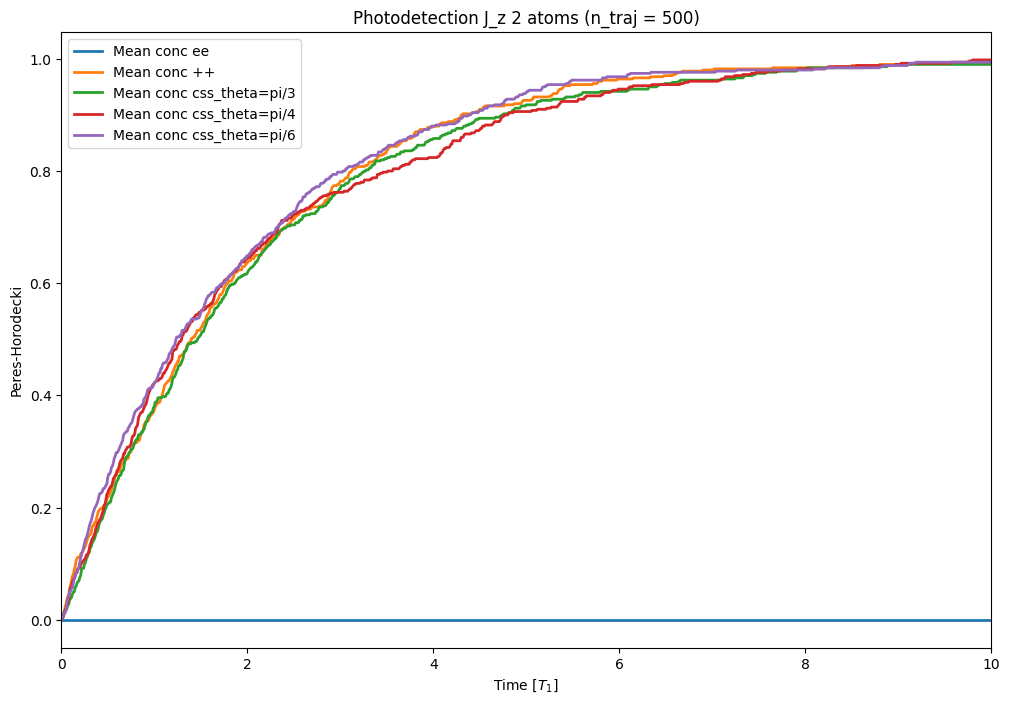

In [27]:
plt.figure(figsize=(12,8))

theo_curves = [(1-np.exp(-2*gamma * times))*np.sin(np.pi/(2*theta)) for theta in [1,2,3,4,6]]

for state,theory in zip(my_name_states, theo_curves):
    line_sim, = plt.plot(times/T_1, 1-abs(photodetection_dfs[f"{state}"]['mean']), label=f"Mean conc {state}", linewidth=2)
    #plt.plot(times/T_1, theory, '--', label=f"Theo conc", color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.xlim(0, 10)
plt.xlabel(r"Time [$T_1$]")
plt.ylabel("Peres-Horodecki")
plt.title(f"Photodetection J_z 2 atoms (n_traj = {ntraj})")
plt.legend()
plt.show()

Tranne per lo stato |ee>, gli altri stati tendono dopo 10*T1 ad essere entangled!

# Test fidelity

Voglio testare la fidelity tra gli stati asintotici e gli stati di Bell, per capire in quale di essi finisco.
Prima vedo qual'è la distanza tra di loro e tra di loro con gli stati di partenza

In [3]:
qutip.fidelity(ee, eg)

np.float64(0.0)

Se gli stati sono entrambi puri, la fidelity si riduce all'overlap! Quindi testato su stati diversi ma della stessa base risulta 0.

Vale 1 SE E SOLO SE i due stati in input sono uguali!

In [4]:
fidelity(eg, psi_plus)

np.float64(0.7071067811865475)

In [2]:
def fidelity_phi_plus(rho):
    return fidelity(rho, phi_plus)

def fidelity_phi_plus_solver(t, rho):
    return fidelity(rho, phi_plus)

def fidelity_phi_minus_solver(t, rho):
    return fidelity(rho, phi_minus)

def fidelity_psi_plus_solver(t, rho):
    return fidelity(rho, psi_plus)

def fidelity_psi_minus_solver(t, rho):
    return fidelity(rho, psi_minus)

fidelity_ops = [
    fidelity_phi_plus_solver,
    fidelity_phi_minus_solver,
    fidelity_psi_plus_solver,
    fidelity_psi_minus_solver]

In [ ]:
gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) # time vector

ntraj = 500 # number of trajectories

my_name_states = ["++"]

my_initial_states = [
    css_2(np.pi/2, phi=0),
]

fidelity_dfs = {}
 
# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma / 2) * (Sz_1-Sz_2)
        ],
        e_ops=fidelity_ops,
        ntraj=ntraj,
        options={"keep_runs_results": True}, #Necessary to create the keep the e_ops results for each trajectory
    )
    
    # raccolgo i risultati finali in una lista di liste
    data = []
    for traj_idx in range(ntraj):
        final_vals = [my_photodetection.expect[i][traj_idx][-1] for i in range(len(fidelity_ops))]
        data.append(final_vals)

    # creo il DataFrame
    fidelity_dfs[f"{name_state}"] = pd.DataFrame(
        data,
        columns=[f.__name__ for f in fidelity_ops],  # i nomi: psi_minus, psi_plus, ...
        index=[f"Traj_{i+1}" for i in range(ntraj)]
        )

10.0%. Run time:   1.75s. Est. time left: 00:00:00:15
20.0%. Run time:   3.41s. Est. time left: 00:00:00:13
30.0%. Run time:   5.30s. Est. time left: 00:00:00:12
40.0%. Run time:   6.93s. Est. time left: 00:00:00:10
50.0%. Run time:   8.84s. Est. time left: 00:00:00:08
60.0%. Run time:  10.54s. Est. time left: 00:00:00:07
70.0%. Run time:  12.23s. Est. time left: 00:00:00:05
80.0%. Run time:  13.98s. Est. time left: 00:00:00:03
90.0%. Run time:  15.79s. Est. time left: 00:00:00:01
100.0%. Run time:  18.41s. Est. time left: 00:00:00:00
Total run time:  18.47s
10.0%. Run time:   1.70s. Est. time left: 00:00:00:15
20.0%. Run time:   3.42s. Est. time left: 00:00:00:13
30.0%. Run time:   5.15s. Est. time left: 00:00:00:12
40.0%. Run time:   6.93s. Est. time left: 00:00:00:10
50.0%. Run time:   8.68s. Est. time left: 00:00:00:08
60.0%. Run time:  10.45s. Est. time left: 00:00:00:06
70.0%. Run time:  12.29s. Est. time left: 00:00:00:05
80.0%. Run time:  14.04s. Est. time left: 00:00:00:03
90.

In [ ]:
for name_state in my_name_states:
    df = fidelity_dfs[f"{name_state}"]
    df["has_one"] = (df> 0.999).any(axis=1)


name_state = "++"

count_psi_plus = fidelity_dfs[name_state]['fidelity_psi_plus_solver'].sum()
count_psi_minus = fidelity_dfs[name_state]['fidelity_psi_minus_solver'].sum()
count_phi_plus = fidelity_dfs[name_state]['fidelity_phi_plus_solver'].sum()
count_phi_minus = fidelity_dfs[name_state]['fidelity_phi_minus_solver'].sum()

print("stato:", name_state)
print("Occorrenze di 1 in psi plus:", count_psi_plus)
print("Occorrenze di 1 in psi minus:", count_psi_minus)
print("Occorrenze di 1 in phi plus:", count_phi_plus)
print("Occorrenze di 1 in phi minus:", count_phi_minus)

fidelity_dfs[name_state]

stato: css_theta=pi/3
Occorrenze di 1 in psi plus: 92.06186217847898
Occorrenze di 1 in psi minus: 92.0
Occorrenze di 1 in phi plus: 207.9121470494135
Occorrenze di 1 in phi minus: 218.66636077044598


,fidelity_phi_plus_solver,fidelity_phi_minus_solver,fidelity_psi_plus_solver,fidelity_psi_minus_solver,has_one
Traj_1,0.000000,0.000000,1.0,0.0,True
Traj_2,0.000000,0.000000,1.0,0.0,True
Traj_3,0.894427,0.447214,0.0,0.0,False
Traj_4,0.000000,0.000000,1.0,0.0,True
Traj_5,0.447214,0.894427,0.0,0.0,False
...,...,...,...,...,...
Traj_496,0.447214,0.894427,0.0,0.0,False
Traj_497,0.000000,0.000000,1.0,0.0,True
Traj_498,0.000000,0.000000,1.0,0.0,True
Traj_499,0.447214,0.894427,0.0,0.0,False


Questo sopra è un df che riporta le 4 quattro fidelity con gli stati Bell dello stato |++> evoluto fino a t=10*T_1 

array([[<Axes: title={'center': 'fidelity_phi_plus_solver'}>,
        <Axes: title={'center': 'fidelity_phi_minus_solver'}>],
       [<Axes: title={'center': 'fidelity_psi_plus_solver'}>,
        <Axes: title={'center': 'fidelity_psi_minus_solver'}>]],
      dtype=object)

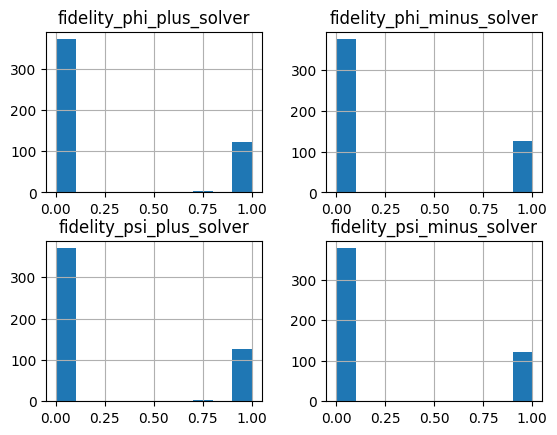

In [13]:
fidelity_dfs["++"].hist()

In [8]:
c_ops =[np.sqrt(gamma) * ((Sz_1+Sz_2)/np.sqrt(2)), np.sqrt(gamma) * ((Sz_1-Sz_2)/np.sqrt(2))]

# E' giusto, basta provare direttamente con tensor(I_2, I_2)/4 - Sz_1*Sz_2
#Ovviamente c'è prima quello col + e poi quello col -

c_daga_c = [c.dag()*c for c in c_ops]
c_daga_c

[Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
 Qobj data =
 [[0.5 0.  0.  0. ]
  [0.  0.  0.  0. ]
  [0.  0.  0.  0. ]
  [0.  0.  0.  0.5]],
 Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
 Qobj data =
 [[0.  0.  0.  0. ]
  [0.  0.5 0.  0. ]
  [0.  0.  0.5 0. ]
  [0.  0.  0.  0. ]]]

In [20]:
gamma = 1   # Atomic decay rate
T_1 = 1 / gamma  # time constant for the decay
dt = 0.01*T_1    # time step

epsilon = gamma * dt

times = np.array(np.arange(0, 10*T_1, dt)) # time vector

ntraj = 500 # number of trajectories

my_name_states = ["ee","++","css_theta=pi/3", "css_theta=pi/4", "css_theta=pi/6"]

my_initial_states = [
    ee,
    css_2(np.pi/2, phi=0),
    css_2(np.pi/3, phi=0),
    css_2(np.pi/4, phi=0),
    css_2(np.pi/6, phi=0)
]

#IL dt E' IMPORTANTEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEE
#dt = 0.01*T_1
def eval_prob_jump(rho, c_daga_c):

    jump_plus = expect(c_daga_c[0], rho)*dt
    jump_minus = expect(c_daga_c[1], rho)*dt

    return jump_plus, jump_minus, jump_plus+jump_minus

for name, state in zip(my_name_states, my_initial_states):
    print(f"Jump probability for state {name}: {eval_prob_jump(state, c_daga_c)}")

#La loro somma coincide con questo!
print(gamma*dt/2)

Jump probability for state ee: (0.004999999999999999, 0.0, 0.004999999999999999)
Jump probability for state ++: (0.0025000000000000005, 0.0025000000000000005, 0.005000000000000001)
Jump probability for state css_theta=pi/3: (0.003125, 0.0018749999999999993, 0.004999999999999999)
Jump probability for state css_theta=pi/4: (0.003749999999999999, 0.00125, 0.004999999999999999)
Jump probability for state css_theta=pi/6: (0.004375, 0.0006249999999999997, 0.005)
0.005


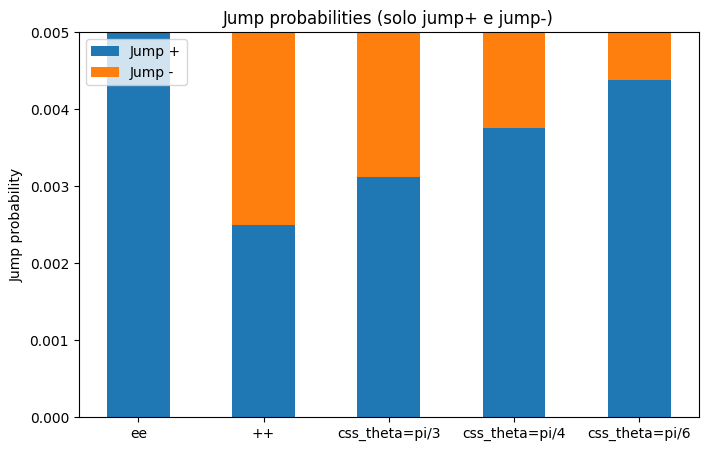

In [21]:
results = []
labels = []

for name, state in zip(my_name_states, my_initial_states):
    jp, jm, _ = eval_prob_jump(state, c_daga_c)  # <-- prendo solo i primi due
    results.append((jp, jm))
    labels.append(name)

# Converto in array
values = np.array(results)

# Asse X
x = np.arange(len(labels))
width = 0.5

# Disegno stacked bar con i primi due valori
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x, values[:,0], width, label='Jump +')
ax.bar(x, values[:,1], width, bottom=values[:,0], label='Jump -')

# Etichette
ax.set_ylabel("Jump probability")
ax.set_title("Jump probabilities (solo jump+ e jump-)")
ax.set_xticks(x)
ax.set_xticklabels(my_name_states)
ax.legend()

# --- Qui sostituiamo il tick 0.005 con epsilon ---
yticks = ax.get_yticks()  # ticks automatici
yticklabels = []
for val in yticks:
    if np.isclose(val, epsilon):  # se coincide con epsilon
        yticklabels.append(r"$\epsilon$")
    else:
        yticklabels.append(f"{val:.3f}")
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

plt.show()


Fissare epsilon o gamma? Meglio Gamma che è più fisico, legato alla teoria microscopica.
Se gamma tende all'infinito (ossia decay rate alto, quasi istant decay) le prob di jump si azzerano?!?

Devo capire perché i grafici della concurrence variano in base a theta...come mai? La prob. di no jump sembra uguale per qualsiasi CSS, indipendente da theta...
Ho qualche differenza tra decadere nel canale + e in quello -? C'è una qualche ragione di simmetria? Il canale + è simmetrico per scambio 1<->2 mentre il - no.

## Spettro comune di Jz e Sz1 - Sz2 / sqrt(2)

In [9]:
#Partiamo (ri)definendo i due operatori, è importante specificare gamma

gamma = 1   # Atomic decay rate

c_ops =[np.sqrt(gamma) * ((Sz_1+Sz_2)/np.sqrt(2)), np.sqrt(gamma) * ((Sz_1-Sz_2)/np.sqrt(2))]
c_daga_c = [c.dag()*c for c in c_ops]

# E' giusto, basta provare direttamente con tensor(I_2, I_2)/4 - Sz_1*Sz_2
#Ovviamente c'è prima quello col + e poi quello col -

c_ops

[Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
 Qobj data =
 [[ 0.70710678  0.          0.          0.        ]
  [ 0.          0.          0.          0.        ]
  [ 0.          0.          0.          0.        ]
  [ 0.          0.          0.         -0.70710678]],
 Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
 Qobj data =
 [[ 0.          0.          0.          0.        ]
  [ 0.          0.70710678  0.          0.        ]
  [ 0.          0.         -0.70710678  0.        ]
  [ 0.          0.          0.          0.        ]]]

In [31]:
eigen_c_plus = c_ops[0].eigenstates()
eigen_c_minus = c_ops[1].eigenstates()

In [ ]:
#Autovalore -1/sqrt(2) per |gg>, +1/sqrt(2) per |ee> e 0 per i due stati |eg> e |ge> 
eigen_c_plus

(array([-0.70710678,  0.        ,  0.        ,  0.70710678]),
 array([Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [0.]
         [1.]]                                                                   ,
        Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [1.]
         [0.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [1.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[1.]
         [0.]
         [0.]
         [0.]]                                                                   ],
       dtype=object))

In [ ]:
#Autovalore -1/sqrt(2) per |ge>, +1/sqrt(2) per |eg> e 0 per i due stati |ee> e |gg> 
eigen_c_minus

(array([-0.70710678,  0.        ,  0.        ,  0.70710678]),
 array([Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [1.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[1.]
         [0.]
         [0.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [0.]
         [1.]]                                                                   ,
        Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [1.]
         [0.]
         [0.]]                                                                   ],
       dtype=object))

In [4]:
Sz_1

Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[ 0.5  0.   0.   0. ]
 [ 0.   0.5  0.   0. ]
 [ 0.   0.  -0.5  0. ]
 [ 0.   0.   0.  -0.5]]

In [5]:
Sz_2

Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[ 0.5  0.   0.   0. ]
 [ 0.  -0.5  0.   0. ]
 [ 0.   0.   0.5  0. ]
 [ 0.   0.   0.  -0.5]]